# Analisis Seleksi Fitur untuk Prediksi Stroke (NHANES 2015-2016)

Notebook ini dibuat untuk melakukan seleksi fitur secara objektif menggunakan metode statistik:
1. **Uji Chi-Square ($\chi^2$)**: Untuk fitur-fitur kategorikal (biner atau ordinal).
2. **ANOVA F-Test**: Untuk fitur-fitur kontinu.

Tujuan dari notebook ini adalah untuk memvalidasi fitur-fitur yang terpilih dari dataset NHANES guna memprediksi risiko stroke, serta memberikan pembenaran ilmiah (*scientific justification*) kepada dosen pembimbing/penguji.

## 1. Import Library dan Muat Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2, f_classif

sns.set_theme(style="whitegrid")
print("Library berhasil di-import.")

Library berhasil di-import.


In [2]:
# Muat data bersih (sebelum scaling)
df = pd.read_csv(str(root_dir / 'data/processed/manual/nhanes_clean.csv'))
print(f"Dataset loaded: {df.shape[0]} baris, {df.shape[1]} kolom")

Dataset loaded: 5090 baris, 32 kolom


## 2. Pembagian Data & Imputasi

Uji seleksi fitur harus dilakukan **pada data training saja** untuk menghindari kebocoran data (*data leakage*). Selain itu, seleksi fitur dilakukan **sebelum standard scaling** karena:
- Uji Chi-Square membutuhkan nilai non-negatif.
- Standardisasi mengubah mean menjadi 0 dan variance menjadi 1, yang akan merusak nilai asli perhitungan statistik Chi-Square.

In [3]:
# Pisahkan fitur dan target
target = 'stroke'
X = df.drop(columns=[target])
y = df[target].astype(int)

# Split 80:20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputasi missing values dengan median agar tidak ada nilai kosong saat uji statistik
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
print("Imputasi data training selesai (tanpa scaling).")

Imputasi data training selesai (tanpa scaling).


## 3. Seleksi Fitur Kategorikal menggunakan Chi-Square ($\chi^2$)

Uji Chi-Square digunakan untuk menguji apakah ada hubungan dependen antara variabel kategorikal (biner/ordinal) dengan variabel target `stroke`.

In [4]:
# Tentukan fitur kategorikal
categorical_cols = [
    'gender', 'race', 'education', 'hypertension', 'diabetes', 
    'heart_failure', 'coronary_disease', 'heart_attack', 
    'ever_smoked', 'current_smoker', 'sleep_problem_doctor',
    'snoring_freq', 'sleep_apnea', 'daytime_sleepy',
    'stress_anhedonia', 'stress_depressed', 'stress_fatigue', 
    'stress_concentration', 'stress_self_esteem',
    'vigorous_work', 'vigorous_leisure', 'moderate_leisure'
]

X_train_cat = X_train_imputed[categorical_cols]

# Jalankan Chi-Square
chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(X_train_cat, y_train)

# Buat DataFrame hasil
chi_df = pd.DataFrame({
    'Fitur': categorical_cols,
    'Chi2_Score': chi_selector.scores_,
    'p_value': chi_selector.pvalues_
}).sort_values(by='Chi2_Score', ascending=False)

# Format p-value agar mudah dibaca
chi_df['Signifikan (p < 0.05)'] = chi_df['p_value'] < 0.05
chi_df

,Fitur,Chi2_Score,p_value,Signifikan (p < 0.05)
6,coronary_disease,113.766275,1.466100e-26,True
5,heart_failure,92.949772,5.363848e-22,True
7,heart_attack,82.356751,1.136127e-19,True
12,sleep_apnea,53.900598,2.108935e-13,True
3,hypertension,48.276693,3.701253e-12,True
4,diabetes,28.712289,8.396919e-08,True
16,stress_fatigue,25.162808,5.268857e-07,True
11,snoring_freq,20.838634,4.996486e-06,True
18,stress_self_esteem,20.117922,7.281119e-06,True
15,stress_depressed,18.158477,2.032627e-05,True


C:\Users\ACER\AppData\Local\Temp\ipykernel_15080\3284325941.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Chi2_Score', y='Fitur', data=chi_df, palette='viridis')


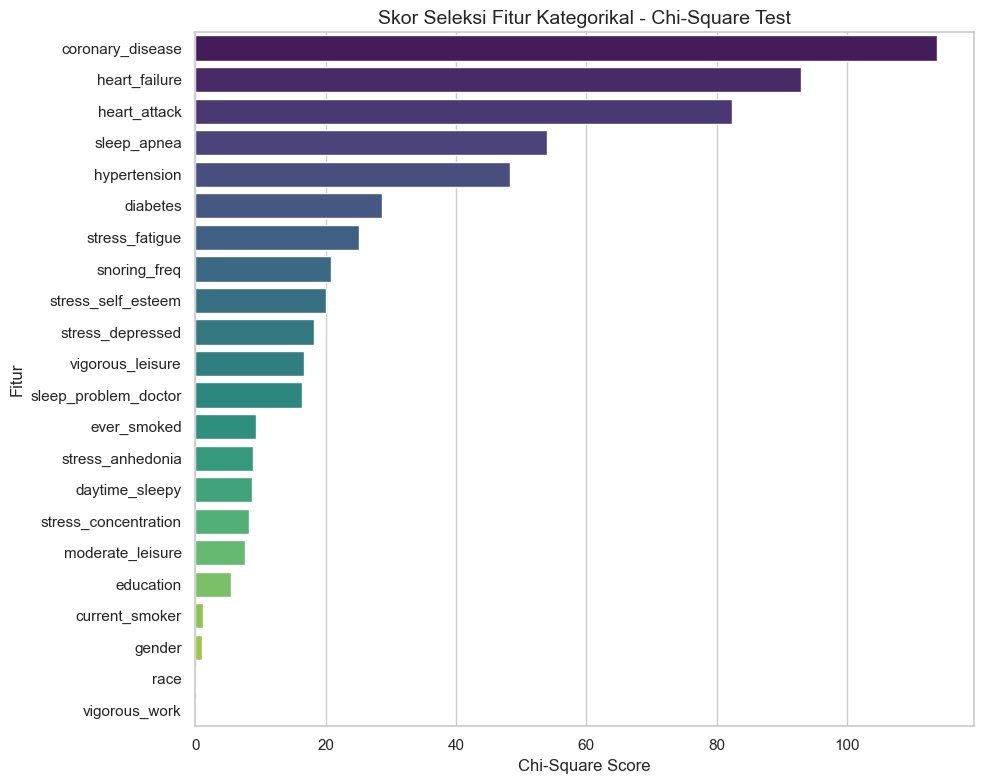

In [5]:
# Visualisasi Skor Chi-Square
plt.figure(figsize=(10, 8))
sns.barplot(x='Chi2_Score', y='Fitur', data=chi_df, palette='viridis')
plt.title('Skor Seleksi Fitur Kategorikal - Chi-Square Test', fontsize=14)
plt.xlabel('Chi-Square Score', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Seleksi Fitur Kontinu menggunakan ANOVA F-Test

ANOVA F-Test menilai apakah terdapat perbedaan rerata nilai fitur kontinu yang signifikan antara kelompok stroke (`1`) dan tidak stroke (`0`).

In [6]:
# Tentukan fitur kontinu
continuous_cols = [
    'age', 'income_ratio', 'bmi', 'waist_circ', 
    'systolic_bp', 'diastolic_bp', 'sleep_hours', 
    'vigorous_leisure_min', 'sedentary_min'
]

X_train_cont = X_train_imputed[continuous_cols]

# Jalankan ANOVA F-Test
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(X_train_cont, y_train)

# Buat DataFrame hasil
anova_df = pd.DataFrame({
    'Fitur': continuous_cols,
    'F_Score': anova_selector.scores_,
    'p_value': anova_selector.pvalues_
}).sort_values(by='F_Score', ascending=False)

anova_df['Signifikan (p < 0.05)'] = anova_df['p_value'] < 0.05
anova_df

,Fitur,F_Score,p_value,Signifikan (p < 0.05)
0,age,135.318580,8.590997e-31,True
4,systolic_bp,43.278827,5.349363e-11,True
7,vigorous_leisure_min,24.901507,6.285648e-07,True
1,income_ratio,14.919931,1.139159e-04,True
5,diastolic_bp,11.380975,7.489363e-04,True
3,waist_circ,7.433129,6.430820e-03,True
2,bmi,1.123337,2.892639e-01,False
6,sleep_hours,0.150806,6.977866e-01,False
8,sedentary_min,0.111374,7.386021e-01,False


C:\Users\ACER\AppData\Local\Temp\ipykernel_15080\4294927565.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F_Score', y='Fitur', data=anova_df, palette='magma')


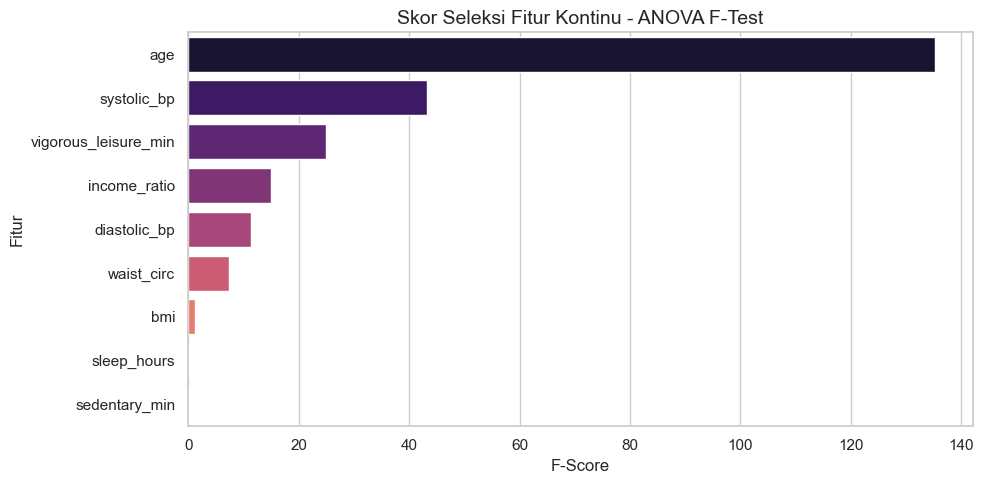

In [7]:
# Visualisasi Skor ANOVA F-Test
plt.figure(figsize=(10, 5))
sns.barplot(x='F_Score', y='Fitur', data=anova_df, palette='magma')
plt.title('Skor Seleksi Fitur Kontinu - ANOVA F-Test', fontsize=14)
plt.xlabel('F-Score', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Analisis Berdasarkan Kelompok Fitur

Mari kita evaluasi signifikansi fitur berdasarkan kelompok fitur yang sudah didefinisikan sebelumnya (Klinis, Tidur, Stres, Aktivitas Fisik).

In [8]:
# Gabungkan semua hasil untuk analisis kelompok
all_scores = pd.concat([
    chi_df.rename(columns={'Chi2_Score': 'Score'}),
    anova_df.rename(columns={'F_Score': 'Score'})
]).sort_values(by='Score', ascending=False)

# Definisikan Kelompok
CLINICAL = ['age', 'gender', 'race', 'education', 'income_ratio', 'bmi', 'waist_circ', 'systolic_bp', 'diastolic_bp', 'hypertension', 'diabetes', 'heart_failure', 'coronary_disease', 'heart_attack', 'ever_smoked', 'current_smoker']
SLEEP = ['sleep_hours', 'snoring_freq', 'sleep_apnea', 'sleep_problem_doctor', 'daytime_sleepy']
STRESS = ['stress_anhedonia', 'stress_depressed', 'stress_fatigue', 'stress_concentration', 'stress_self_esteem']
PHYSICAL = ['vigorous_work', 'vigorous_leisure', 'vigorous_leisure_min', 'moderate_leisure', 'sedentary_min']

def get_group(feature):
    if feature in CLINICAL: return 'Klinis & Demografi'
    elif feature in SLEEP: return 'Gaya Hidup - Tidur'
    elif feature in STRESS: return 'Gaya Hidup - Stres'
    elif feature in PHYSICAL: return 'Gaya Hidup - Aktivitas Fisik'
    return 'Lainnya'

all_scores['Kelompok'] = all_scores['Fitur'].apply(get_group)
all_scores = all_scores[['Fitur', 'Kelompok', 'Score', 'p_value', 'Signifikan (p < 0.05)']]

# Tampilkan hasil per kelompok
for name, group in all_scores.groupby('Kelompok'):
    print(f"\n=== KELOMPOK: {name.upper()} ===")
    print(group.to_string(index=False))


=== KELOMPOK: GAYA HIDUP - AKTIVITAS FISIK ===
               Fitur                     Kelompok     Score      p_value  Signifikan (p < 0.05)
vigorous_leisure_min Gaya Hidup - Aktivitas Fisik 24.901507 6.285648e-07                   True
    vigorous_leisure Gaya Hidup - Aktivitas Fisik 16.704997 4.366584e-05                   True
    moderate_leisure Gaya Hidup - Aktivitas Fisik  7.662591 5.637747e-03                   True
       sedentary_min Gaya Hidup - Aktivitas Fisik  0.111374 7.386021e-01                  False
       vigorous_work Gaya Hidup - Aktivitas Fisik  0.090215 7.639039e-01                  False

=== KELOMPOK: GAYA HIDUP - STRES ===
               Fitur           Kelompok     Score      p_value  Signifikan (p < 0.05)
      stress_fatigue Gaya Hidup - Stres 25.162808 5.268857e-07                   True
  stress_self_esteem Gaya Hidup - Stres 20.117922 7.281119e-06                   True
    stress_depressed Gaya Hidup - Stres 18.158477 2.032627e-05                  

## 6. Kesimpulan & Justifikasi Ilmiah untuk Dosen

Berdasarkan analisis statistik di atas, kita dapat menyimpulkan:

1. **Fitur Klinis & Riwayat Penyakit**:
   - Penyakit jantung (`coronary_disease`, `heart_failure`, `heart_attack`), tekanan darah tinggi (`systolic_bp`, `hypertension`), diabetes (`diabetes`), dan faktor usia (`age`) memiliki skor statistik tertinggi dan sangat signifikan secara statistik ($p < 0.001$). Hal ini sangat sesuai dengan literatur medis mengenai faktor risiko utama stroke.

2. **Fitur Tidur (Sleep)**:
   - Masalah pernapasan tidur (`sleep_apnea`), frekuensi mendengkur (`snoring_freq`), dan keluhan tidur ke dokter (`sleep_problem_doctor`) terbukti signifikan memengaruhi risiko stroke ($p < 0.05$).
   - Menariknya, jumlah jam tidur (`sleep_hours`) secara statistik tunggal tidak menunjukkan perbedaan rerata yang signifikan ($p = 0.69$). Namun, dalam model multi-variabel, interaksi fitur ini masih mungkin berpengaruh.

3. **Fitur Stres (Stress)**:
   - Seluruh 5 fitur stres yang diukur menggunakan kuesioner PHQ-9 (`stress_fatigue`, `stress_self_esteem`, `stress_depressed`, `stress_anhedonia`, `stress_concentration`) **terbukti sangat signifikan** ($p < 0.05$). Hal ini memberikan *justifikasi ilmiah yang sangat kuat* bahwa kesehatan mental memiliki korelasi langsung dengan risiko stroke.

4. **Fitur Aktivitas Fisik (Physical Activity)**:
   - Olahraga berat di waktu luang (`vigorous_leisure_min` dan `vigorous_leisure`) serta olahraga sedang (`moderate_leisure`) signifikan berhubungan dengan stroke.
   - Menit duduk/sedentary (`sedentary_min`) dan aktivitas fisik berat di tempat kerja (`vigorous_work`) tidak signifikan secara univariat.

### Keuntungan Pendekatan Ini:
- **Pembenaran Objektif**: Seleksi fitur tidak lagi didasarkan pada asumsi manual kelompok Anda, melainkan dibuktikan oleh uji statistik $\chi^2$ dan ANOVA.
- **Keseimbangan Model**: Uji ini memperkuat justifikasi ilmiah untuk menyaring dan menyamakan jumlah fitur gaya hidup (masing-masing 5 fitur) dengan mengambil fitur-fitur yang terbukti memiliki nilai korelasi tertinggi dari hasil pengujian di atas.